In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from scipy import stats
from scipy.stats.mstats import winsorize

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.compose import ColumnTransformer

## Loading Dataset : ( Manufacturing Dataset )

In [2]:
Original_Data = pd.read_csv("smart_manufacturing_dataset.csv")

df = Original_Data.copy()

df.head()

,Machine_ID,Machine_Type,Factory_Location,Operating_Hours_Per_Day,Energy_Consumption_kWh,Production_Output_Units,Defect_Rate_Percent,Maintenance_Level,Temperature_Celsius,Worker_Count,Downtime_Hours_Per_Month,Shift_Type,Last_Service_Date,Supervisor_Name,Efficiency_Score
0,MCH-1000,3D Printer,Rajkot,11,1012.30,1685,9.02,Low,33.3,25,13.3,Evening,2023-12-28,Richard,85.25
1,MCH-1001,NaN,Surat,19,242.66,333,2.03,Medium,23.7,19,1.9,Evening,2023-05-05,Brian,97.04
2,MCH-1002,3D Printer,Vadodara,22,802.90,1349,10.50,High,22.5,26,1.9,Morning,2023-07-03,Krista,87.76
3,MCH-1003,Laser Cutter,Vadodara,20,1614.56,1963,12.06,High,37.0,17,115.8,Morning,2023-03-17,David,78.44
4,MCH-1004,Packaging Unit,Surat,21,694.18,546,11.42,High,29.9,12,1.3,Night,2024-01-15,Sarah,79.81


## Basic Info :

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6620 entries, 0 to 6619
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Machine_ID                6620 non-null   object 
 1   Machine_Type              6222 non-null   object 
 2   Factory_Location          6620 non-null   object 
 3   Operating_Hours_Per_Day   6620 non-null   int64  
 4   Energy_Consumption_kWh    6219 non-null   float64
 5   Production_Output_Units   6620 non-null   int64  
 6   Defect_Rate_Percent       6620 non-null   float64
 7   Maintenance_Level         6238 non-null   object 
 8   Temperature_Celsius       6219 non-null   float64
 9   Worker_Count              6620 non-null   int64  
 10  Downtime_Hours_Per_Month  6620 non-null   float64
 11  Shift_Type                6620 non-null   object 
 12  Last_Service_Date         6620 non-null   object 
 13  Supervisor_Name           6225 non-null   object 
 14  Efficien

,Operating_Hours_Per_Day,Energy_Consumption_kWh,Production_Output_Units,Defect_Rate_Percent,Temperature_Celsius,Worker_Count,Downtime_Hours_Per_Month,Efficiency_Score
count,6620.000000,6219.000000,6620.000000,6620.000000,6219.000000,6620.000000,6620.000000,6620.000000
mean,13.452115,740.555924,1020.795921,7.529435,29.913925,15.645166,8.091994,86.908505
std,5.819460,592.291632,556.633904,4.273597,5.893746,8.172353,8.679691,11.225794
min,4.000000,30.720000,50.000000,0.100000,5.000000,2.000000,0.000000,30.500000
25%,8.000000,445.945000,546.000000,3.950000,25.900000,9.000000,2.300000,79.155000
50%,13.000000,657.120000,1025.000000,7.420000,29.900000,16.000000,5.600000,87.295000
75%,19.000000,910.445000,1492.000000,11.220000,33.900000,23.000000,11.025000,95.100000
max,23.000000,14027.280000,1999.000000,15.000000,53.700000,29.000000,151.200000,114.380000


## Missing Value Identification :

In [4]:
missing_count = df.isnull().sum()
missing_percent = (missing_count/len(df))*100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage(%)':missing_percent 
})

missing_df

,Missing Count,Percentage(%)
Machine_ID,0,0.000000
Machine_Type,398,6.012085
Factory_Location,0,0.000000
Operating_Hours_Per_Day,0,0.000000
Energy_Consumption_kWh,401,6.057402
Production_Output_Units,0,0.000000
Defect_Rate_Percent,0,0.000000
Maintenance_Level,382,5.770393
Temperature_Celsius,401,6.057402
Worker_Count,0,0.000000


## Dropping Unnecessary Features :

In [5]:
df = df.drop(columns=['Machine_ID','Supervisor_Name'])


In [6]:
df.dtypes

Machine_Type                 object
Factory_Location             object
Operating_Hours_Per_Day       int64
Energy_Consumption_kWh      float64
Production_Output_Units       int64
Defect_Rate_Percent         float64
Maintenance_Level            object
Temperature_Celsius         float64
Worker_Count                  int64
Downtime_Hours_Per_Month    float64
Shift_Type                   object
Last_Service_Date            object
Efficiency_Score            float64
dtype: object

## Checking Distribution : (Missing Numerical Feature Only)

In [7]:
missing_numeric = df[['Energy_Consumption_kWh' , 'Temperature_Celsius']]

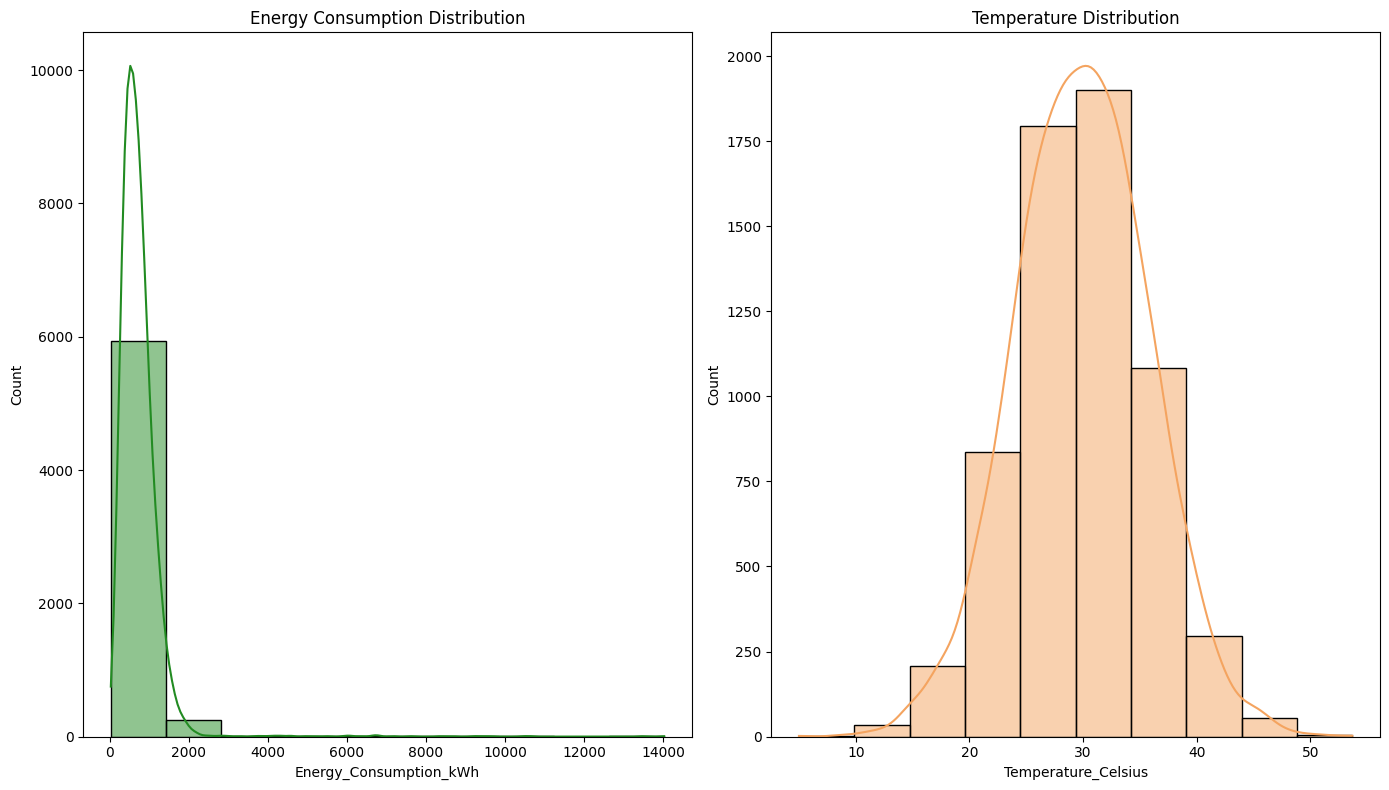

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.histplot(df['Energy_Consumption_kWh'], bins=10, kde=True, ax=axes[0], color='forestgreen')
axes[0].set_title('Energy Consumption Distribution')

sns.histplot(df['Temperature_Celsius'], bins=10, kde=True, ax=axes[1], color='sandybrown')
axes[1].set_title('Temperature Distribution')

plt.tight_layout()
plt.show()

## Missing Value Imputation :

In [9]:
median_imputer = SimpleImputer(strategy="median")

df["Energy_Consumption_kWh"] = median_imputer.fit_transform(df[["Energy_Consumption_kWh"]])

In [10]:
mean_imputer = SimpleImputer(strategy='mean')

df['Temperature_Celsius'] = mean_imputer.fit_transform(df[['Temperature_Celsius']])

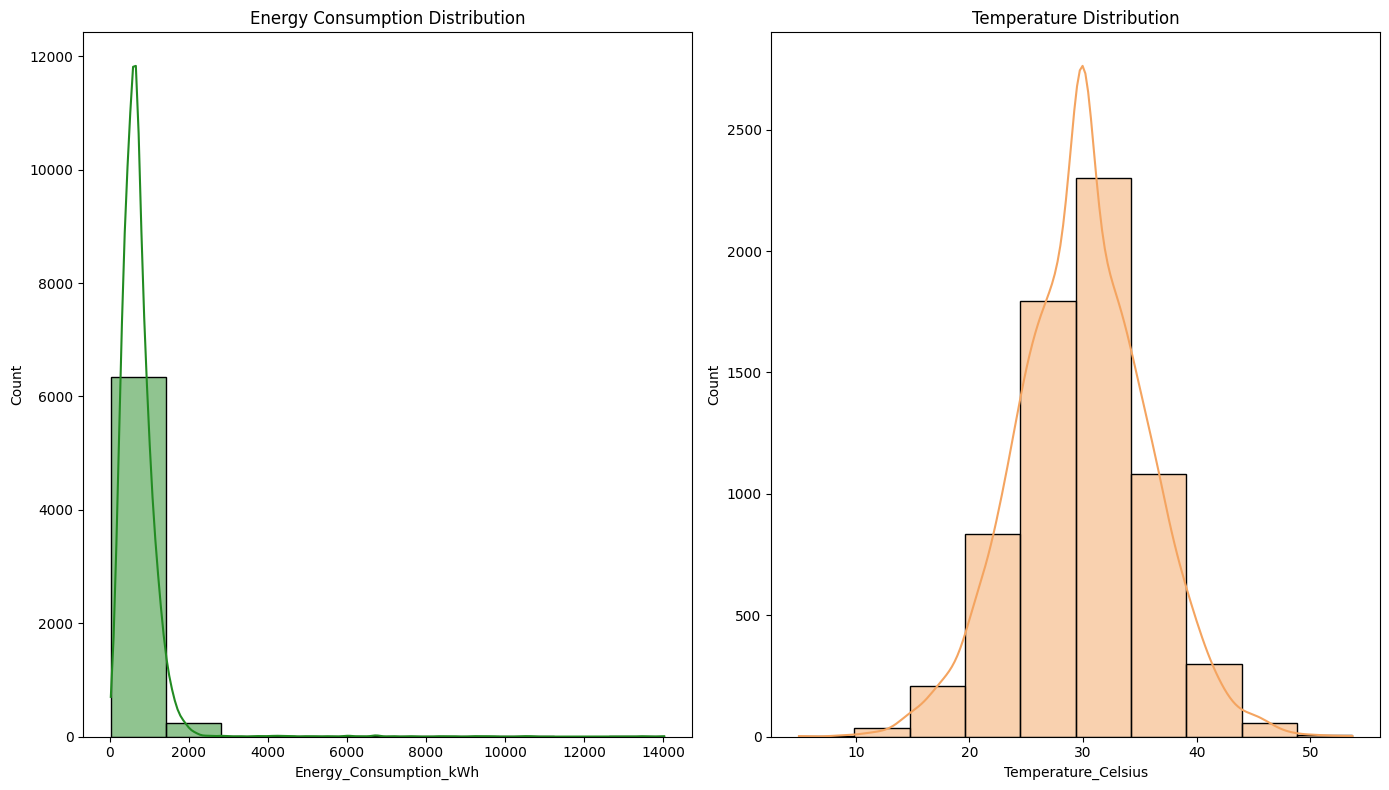

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.histplot(df['Energy_Consumption_kWh'], bins=10, kde=True, ax=axes[0], color='forestgreen')
axes[0].set_title('Energy Consumption Distribution')

sns.histplot(df['Temperature_Celsius'], bins=10, kde=True, ax=axes[1], color='sandybrown')
axes[1].set_title('Temperature Distribution')

plt.tight_layout()
plt.show()

In [12]:
missing_categorical = df[['Maintenance_Level','Machine_Type']]

def random_impute(col):

    values = col.dropna().values
    
    return col.apply(lambda x: np.random.choice(values) if pd.isna(x) else x)

df['Maintenance_Level'] = random_impute(df['Maintenance_Level'])
df['Machine_Type'] = random_impute(df['Machine_Type'])

In [13]:
df.isnull().sum()

Machine_Type                0
Factory_Location            0
Operating_Hours_Per_Day     0
Energy_Consumption_kWh      0
Production_Output_Units     0
Defect_Rate_Percent         0
Maintenance_Level           0
Temperature_Celsius         0
Worker_Count                0
Downtime_Hours_Per_Month    0
Shift_Type                  0
Last_Service_Date           0
Efficiency_Score            0
dtype: int64

## Outlier Handling :

In [14]:
Q1 = df["Energy_Consumption_kWh"].quantile(0.25)
Q3 = df["Energy_Consumption_kWh"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["Energy_Consumption_kWh"] = np.clip(df["Energy_Consumption_kWh"], lower , upper)

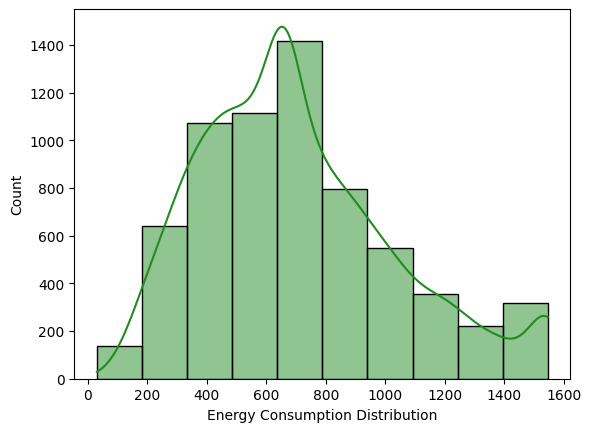

In [15]:
sns.histplot(df['Energy_Consumption_kWh'], bins=10, kde=True, color='forestgreen')
plt.xlabel('Energy Consumption Distribution')
plt.show()

## Function Transformer :

In [16]:
df["Energy_Consumption_kWh"] = np.log1p(df["Energy_Consumption_kWh"])

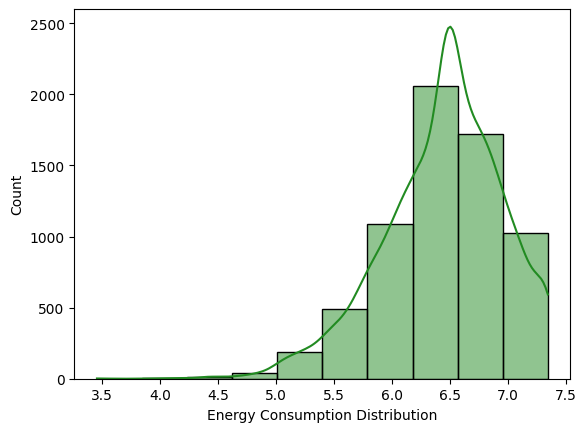

In [17]:
sns.histplot(df['Energy_Consumption_kWh'], bins=10, kde=True, color='forestgreen')
plt.xlabel('Energy Consumption Distribution')
plt.show()

In [18]:
df

,Machine_Type,Factory_Location,Operating_Hours_Per_Day,Energy_Consumption_kWh,Production_Output_Units,Defect_Rate_Percent,Maintenance_Level,Temperature_Celsius,Worker_Count,Downtime_Hours_Per_Month,Shift_Type,Last_Service_Date,Efficiency_Score
0,3D Printer,Rajkot,11,6.920968,1685,9.02,Low,33.3,25,13.3,Evening,2023-12-28,85.25
1,Laser Cutter,Surat,19,5.495774,333,2.03,Medium,23.7,19,1.9,Evening,2023-05-05,97.04
2,3D Printer,Vadodara,22,6.689475,1349,10.50,High,22.5,26,1.9,Morning,2023-07-03,87.76
3,Laser Cutter,Vadodara,20,7.344301,1963,12.06,High,37.0,17,115.8,Morning,2023-03-17,78.44
4,Packaging Unit,Surat,21,6.544171,546,11.42,High,29.9,12,1.3,Night,2024-01-15,79.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6615,Robotic Arm,Surat,13,6.126192,971,3.88,Low,30.1,22,9.7,Night,2022-09-08,92.89
6616,Packaging Unit,Ahmedabad,5,6.928753,1750,0.28,Low,22.3,26,3.2,Evening,2022-01-24,110.33
6617,Packaging Unit,Surat,19,6.536155,882,6.70,High,31.3,25,0.8,Evening,2023-12-30,92.41
6618,Packaging Unit,Vadodara,9,7.074210,1176,4.72,Low,30.6,24,4.1,Morning,2024-02-20,95.80


## Feature Engineering & Encoding :

In [19]:
df["Last_Service_Date"] = pd.to_datetime(df["Last_Service_Date"])

current_date = pd.Timestamp.today()

df["Days_Since_Service"] = (current_date - df["Last_Service_Date"]).dt.days
df["Service_Year"] = df["Last_Service_Date"].dt.year
df["Service_Month"] = df["Last_Service_Date"].dt.month
df["Service_Day"] = df["Last_Service_Date"].dt.day

In [20]:
df = df.drop(columns=['Last_Service_Date'])

In [21]:
df["Output_Per_Worker"] = (
    df["Production_Output_Units"] /
    df["Worker_Count"]
)

In [22]:
df["Energy_Per_Unit"] = (
    df["Energy_Consumption_kWh"] /
    df["Production_Output_Units"]
)

In [23]:
df

,Machine_Type,Factory_Location,Operating_Hours_Per_Day,Energy_Consumption_kWh,Production_Output_Units,Defect_Rate_Percent,Maintenance_Level,Temperature_Celsius,Worker_Count,Downtime_Hours_Per_Month,Shift_Type,Efficiency_Score,Days_Since_Service,Service_Year,Service_Month,Service_Day,Output_Per_Worker,Energy_Per_Unit
0,3D Printer,Rajkot,11,6.920968,1685,9.02,Low,33.3,25,13.3,Evening,85.25,863,2023,12,28,67.400000,0.004107
1,Laser Cutter,Surat,19,5.495774,333,2.03,Medium,23.7,19,1.9,Evening,97.04,1100,2023,5,5,17.526316,0.016504
2,3D Printer,Vadodara,22,6.689475,1349,10.50,High,22.5,26,1.9,Morning,87.76,1041,2023,7,3,51.884615,0.004959
3,Laser Cutter,Vadodara,20,7.344301,1963,12.06,High,37.0,17,115.8,Morning,78.44,1149,2023,3,17,115.470588,0.003741
4,Packaging Unit,Surat,21,6.544171,546,11.42,High,29.9,12,1.3,Night,79.81,845,2024,1,15,45.500000,0.011986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6615,Robotic Arm,Surat,13,6.126192,971,3.88,Low,30.1,22,9.7,Night,92.89,1339,2022,9,8,44.136364,0.006309
6616,Packaging Unit,Ahmedabad,5,6.928753,1750,0.28,Low,22.3,26,3.2,Evening,110.33,1566,2022,1,24,67.307692,0.003959
6617,Packaging Unit,Surat,19,6.536155,882,6.70,High,31.3,25,0.8,Evening,92.41,861,2023,12,30,35.280000,0.007411
6618,Packaging Unit,Vadodara,9,7.074210,1176,4.72,Low,30.6,24,4.1,Morning,95.80,809,2024,2,20,49.000000,0.006015


In [24]:
df['Output_Per_Worker'] = df['Output_Per_Worker'].round(1)
df['Energy_Per_Unit'] = df['Energy_Per_Unit'].round(3)

In [25]:
df

,Machine_Type,Factory_Location,Operating_Hours_Per_Day,Energy_Consumption_kWh,Production_Output_Units,Defect_Rate_Percent,Maintenance_Level,Temperature_Celsius,Worker_Count,Downtime_Hours_Per_Month,Shift_Type,Efficiency_Score,Days_Since_Service,Service_Year,Service_Month,Service_Day,Output_Per_Worker,Energy_Per_Unit
0,3D Printer,Rajkot,11,6.920968,1685,9.02,Low,33.3,25,13.3,Evening,85.25,863,2023,12,28,67.4,0.004
1,Laser Cutter,Surat,19,5.495774,333,2.03,Medium,23.7,19,1.9,Evening,97.04,1100,2023,5,5,17.5,0.017
2,3D Printer,Vadodara,22,6.689475,1349,10.50,High,22.5,26,1.9,Morning,87.76,1041,2023,7,3,51.9,0.005
3,Laser Cutter,Vadodara,20,7.344301,1963,12.06,High,37.0,17,115.8,Morning,78.44,1149,2023,3,17,115.5,0.004
4,Packaging Unit,Surat,21,6.544171,546,11.42,High,29.9,12,1.3,Night,79.81,845,2024,1,15,45.5,0.012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6615,Robotic Arm,Surat,13,6.126192,971,3.88,Low,30.1,22,9.7,Night,92.89,1339,2022,9,8,44.1,0.006
6616,Packaging Unit,Ahmedabad,5,6.928753,1750,0.28,Low,22.3,26,3.2,Evening,110.33,1566,2022,1,24,67.3,0.004
6617,Packaging Unit,Surat,19,6.536155,882,6.70,High,31.3,25,0.8,Evening,92.41,861,2023,12,30,35.3,0.007
6618,Packaging Unit,Vadodara,9,7.074210,1176,4.72,Low,30.6,24,4.1,Morning,95.80,809,2024,2,20,49.0,0.006


In [26]:
df['Machine_Type'].value_counts()

Machine_Type
Packaging Unit    1363
Laser Cutter      1326
CNC               1319
3D Printer        1317
Robotic Arm       1295
Name: count, dtype: int64

In [27]:
df['Maintenance_Level'].value_counts()

Maintenance_Level
High      2216
Medium    2145
Low       2100
HIGH       159
Name: count, dtype: int64

In [28]:
df["Maintenance_Level"] = (
    df["Maintenance_Level"]
    .str.lower()
)

In [29]:
df['Maintenance_Level'].value_counts()

Maintenance_Level
high      2375
medium    2145
low       2100
Name: count, dtype: int64

In [30]:
Ord_enc = OrdinalEncoder(
    categories=[['low' , 'medium' , 'high']]
)

df['Maintenance_Level'] = Ord_enc.fit_transform(df[['Maintenance_Level']])

In [31]:
df['Shift_Type'].value_counts()

Shift_Type
Night      2196
Morning    2121
Evening    2106
morning     197
Name: count, dtype: int64

In [32]:
df["Shift_Type"] = (
    df["Shift_Type"]
    .str.lower()
)

In [33]:
df['Shift_Type'].value_counts()

Shift_Type
morning    2318
night      2196
evening    2106
Name: count, dtype: int64

In [34]:
ohe = OneHotEncoder( drop = 'first', sparse_output = False , handle_unknown = 'ignore')   

cat_cols = ['Machine_Type' , 'Factory_Location' , 'Shift_Type']

encoded_array = ohe.fit_transform(df[cat_cols])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(cat_cols),
    index=df.index
)

df = df.drop(columns=cat_cols)
df = pd.concat([df, encoded_df], axis=1)

In [35]:
df

,Operating_Hours_Per_Day,Energy_Consumption_kWh,Production_Output_Units,Defect_Rate_Percent,Maintenance_Level,Temperature_Celsius,Worker_Count,Downtime_Hours_Per_Month,Efficiency_Score,Days_Since_Service,...,Machine_Type_CNC,Machine_Type_Laser Cutter,Machine_Type_Packaging Unit,Machine_Type_Robotic Arm,Factory_Location_Pune,Factory_Location_Rajkot,Factory_Location_Surat,Factory_Location_Vadodara,Shift_Type_morning,Shift_Type_night
0,11,6.920968,1685,9.02,0.0,33.3,25,13.3,85.25,863,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,19,5.495774,333,2.03,1.0,23.7,19,1.9,97.04,1100,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,22,6.689475,1349,10.50,2.0,22.5,26,1.9,87.76,1041,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,20,7.344301,1963,12.06,2.0,37.0,17,115.8,78.44,1149,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,21,6.544171,546,11.42,2.0,29.9,12,1.3,79.81,845,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6615,13,6.126192,971,3.88,0.0,30.1,22,9.7,92.89,1339,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
6616,5,6.928753,1750,0.28,0.0,22.3,26,3.2,110.33,1566,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6617,19,6.536155,882,6.70,2.0,31.3,25,0.8,92.41,861,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6618,9,7.074210,1176,4.72,0.0,30.6,24,4.1,95.80,809,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


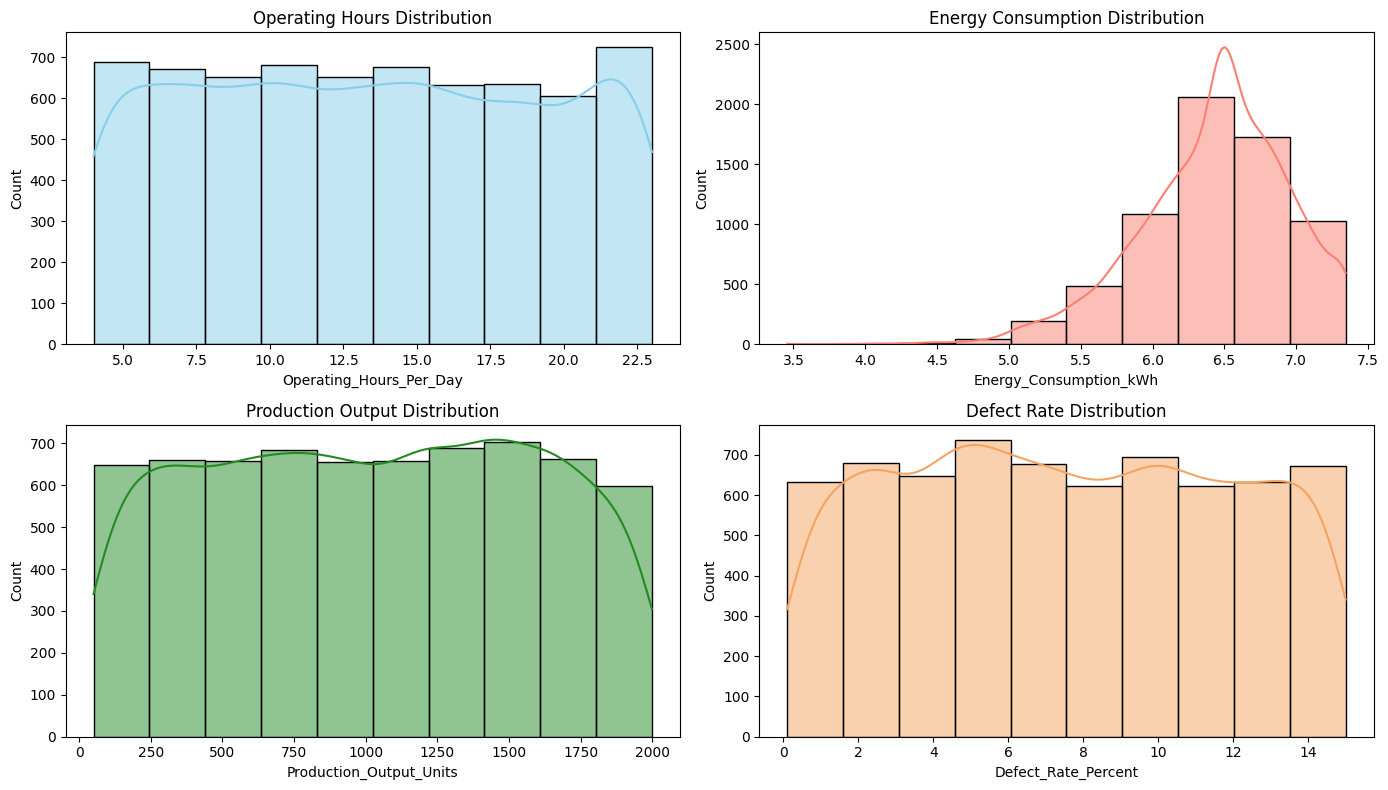

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df['Operating_Hours_Per_Day'], bins=10, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Operating Hours Distribution')

sns.histplot(df['Energy_Consumption_kWh'], bins=10, kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Energy Consumption Distribution')

sns.histplot(df['Production_Output_Units'], bins=10, kde=True, ax=axes[1,0], color='forestgreen')
axes[1,0].set_title('Production Output Distribution')

sns.histplot(df['Defect_Rate_Percent'], bins=10, kde=True, ax=axes[1,1], color='sandybrown')
axes[1,1].set_title('Defect Rate Distribution')

plt.tight_layout()
plt.show()

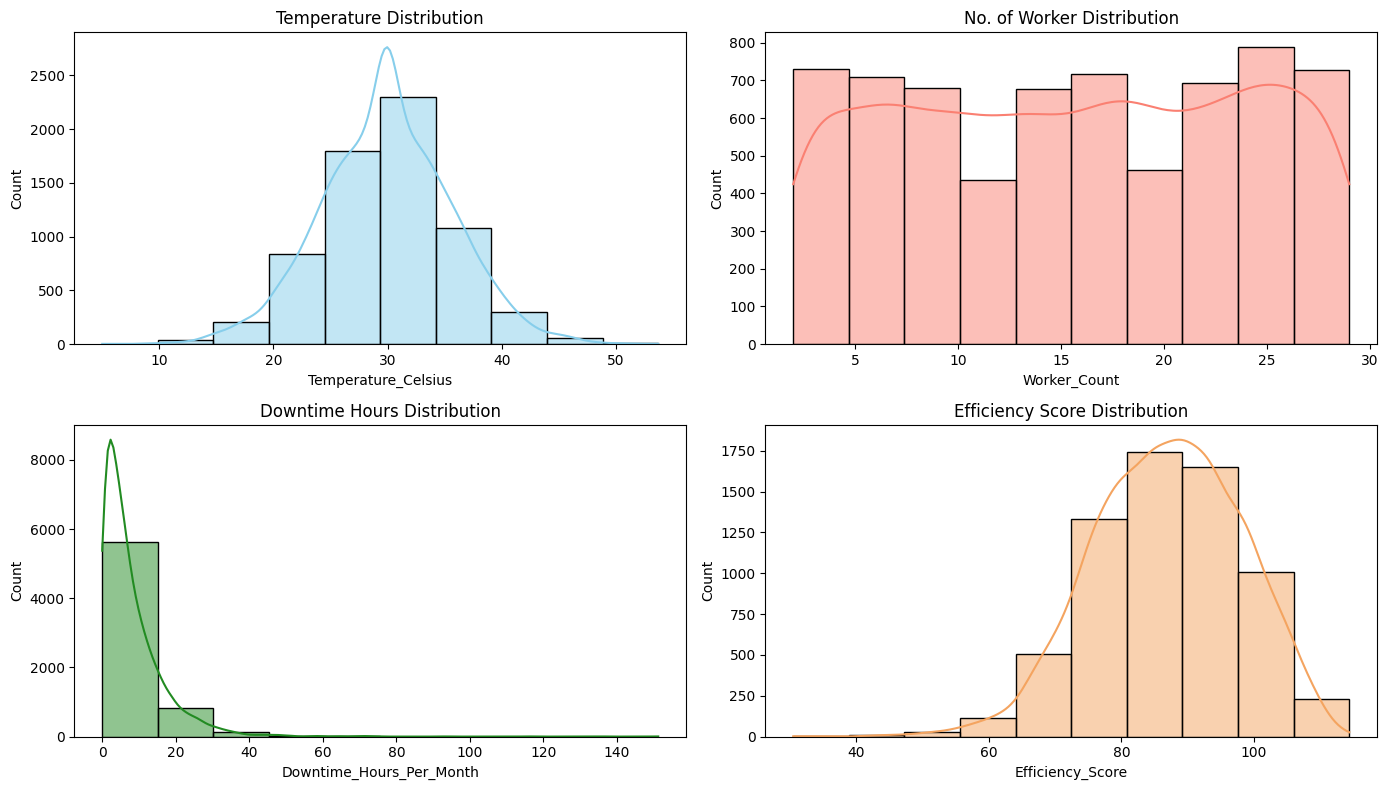

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df['Temperature_Celsius'], bins=10, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Temperature Distribution')

sns.histplot(df['Worker_Count'], bins=10, kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('No. of Worker Distribution')

sns.histplot(df['Downtime_Hours_Per_Month'], bins=10, kde=True, ax=axes[1,0], color='forestgreen')
axes[1,0].set_title('Downtime Hours Distribution')

sns.histplot(df['Efficiency_Score'], bins=10, kde=True, ax=axes[1,1], color='sandybrown')
axes[1,1].set_title('Efficiency Score Distribution')

plt.tight_layout()
plt.show()

## Function Transformer

In [38]:
df["Downtime_Hours_Per_Month"] = np.log1p(df["Downtime_Hours_Per_Month"])

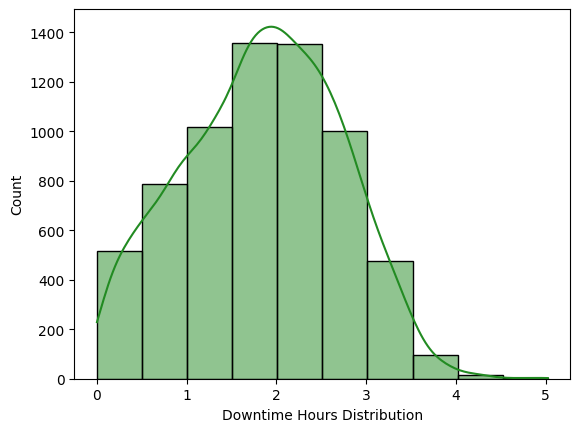

In [39]:
sns.histplot(df['Downtime_Hours_Per_Month'], bins=10, kde=True, color='forestgreen')
plt.xlabel('Downtime Hours Distribution')
plt.show()

In [40]:
df

,Operating_Hours_Per_Day,Energy_Consumption_kWh,Production_Output_Units,Defect_Rate_Percent,Maintenance_Level,Temperature_Celsius,Worker_Count,Downtime_Hours_Per_Month,Efficiency_Score,Days_Since_Service,...,Machine_Type_CNC,Machine_Type_Laser Cutter,Machine_Type_Packaging Unit,Machine_Type_Robotic Arm,Factory_Location_Pune,Factory_Location_Rajkot,Factory_Location_Surat,Factory_Location_Vadodara,Shift_Type_morning,Shift_Type_night
0,11,6.920968,1685,9.02,0.0,33.3,25,2.660260,85.25,863,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,19,5.495774,333,2.03,1.0,23.7,19,1.064711,97.04,1100,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,22,6.689475,1349,10.50,2.0,22.5,26,1.064711,87.76,1041,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,20,7.344301,1963,12.06,2.0,37.0,17,4.760463,78.44,1149,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,21,6.544171,546,11.42,2.0,29.9,12,0.832909,79.81,845,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6615,13,6.126192,971,3.88,0.0,30.1,22,2.370244,92.89,1339,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
6616,5,6.928753,1750,0.28,0.0,22.3,26,1.435085,110.33,1566,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6617,19,6.536155,882,6.70,2.0,31.3,25,0.587787,92.41,861,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6618,9,7.074210,1176,4.72,0.0,30.6,24,1.629241,95.80,809,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


## Feature Scaling :

In [41]:
scale_cols = [
    "Operating_Hours_Per_Day","Energy_Consumption_kWh","Production_Output_Units",
    "Defect_Rate_Percent","Temperature_Celsius","Worker_Count",
    "Downtime_Hours_Per_Month","Days_Since_Service","Output_Per_Worker","Energy_Per_Unit"
]

scaler = StandardScaler()

df[scale_cols] = scaler.fit_transform(df[scale_cols])

In [42]:
Cleaned_Dataset = df.copy()

Cleaned_Dataset.head()

,Operating_Hours_Per_Day,Energy_Consumption_kWh,Production_Output_Units,Defect_Rate_Percent,Maintenance_Level,Temperature_Celsius,Worker_Count,Downtime_Hours_Per_Month,Efficiency_Score,Days_Since_Service,...,Machine_Type_CNC,Machine_Type_Laser Cutter,Machine_Type_Packaging Unit,Machine_Type_Robotic Arm,Factory_Location_Pune,Factory_Location_Rajkot,Factory_Location_Surat,Factory_Location_Vadodara,Shift_Type_morning,Shift_Type_night
0,-0.421396,0.934800,1.193341,0.348811,0.0,0.592801,1.144779,0.937362,85.25,-0.380295,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.953405,-1.830408,-1.235728,-1.286937,1.0,-1.087873,0.410541,-0.892337,97.04,0.303166,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.468956,0.485651,0.589667,0.695150,2.0,-1.297957,1.267152,-0.892337,87.76,0.133022,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,1.125256,1.756165,1.692810,1.060209,2.0,1.240561,0.165795,3.345776,78.44,0.444472,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,1.297106,0.203727,-0.853041,0.910441,2.0,-0.002438,-0.446070,-1.158157,79.81,-0.432203,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
